# Selkov oscillator + Goldilocks field arithmetic — verified RTL

**Two independent cores, each with a test that could fail.**

| core | claim | how it's checked |
|---|---|---|
| `selkov` | implements dx/dt = −x + ay + x²y, dy/dt = b − ay − x²y in Q8.24 | fixed-point output compared against a float integration of the *same* equations |
| `goldilocks_reduce` | fast reduction mod p = 2⁶⁴ − 2³² + 1, no divider | compared bit-for-bit against the `%` operator on random + edge vectors |

### What this is NOT

- **Not a prover.** There is no constraint system, no polynomial commitment, no Fiat–Shamir, no verifier. `goldilocks_mul` is a *modular multiplier*. A witness is not a proof.
- **Not an FPGA timing result.** Gate counts come from generic Yosys synthesis. Real Fmax and DSP mapping require Vivado and a board.
- **Not self-improving.** `a`, `b`, `dt` are inputs. Nothing writes to them based on any measured outcome. It is an open-loop integrator.

### Bugs this version fixes

1. `x_sq` used but never declared → `` `default_nettype none `` makes any implicit wire a compile error.
2. `dx`/`dy` referenced but never computed → the `*dt` step now exists.
3. C braces `{ }` where Verilog needs `begin`/`end`.
4. `mult()` silently truncated on overflow → arithmetic now saturates and raises a sticky flag.
5. Equations disagreed between spec and code → the header states them, and the float check enforces it.
6. `(x*x) % PRIME` with a 32-bit input: the modulo **never fires**, because (2³²−1)² < p. Dead code. Inputs are now 64-bit so reduction actually happens.


## 1. Toolchain

In [ ]:
import os, subprocess, textwrap
print("installing iverilog + yosys ...")
os.system("apt-get update -y -qq > /dev/null 2>&1")
os.system("apt-get install -y -qq iverilog yosys > /dev/null 2>&1")
os.system("pip install -q pandas matplotlib numpy > /dev/null 2>&1")
print(subprocess.run("iverilog -V | head -1", shell=True, capture_output=True, text=True).stdout.strip())
print(subprocess.run("yosys -V", shell=True, capture_output=True, text=True).stdout.strip())

installing iverilog + yosys ...
Icarus Verilog version 11.0 (stable) ()
Yosys 0.9 (git sha1 1979e0b)


## 2. Selkov core

Equations are stated in the header in the same notation as the spec, along with the stability
condition. Note the parameter choice matters: the Hopf condition at the fixed point
x\* = b, y\* = b/(a+b²) is

$$\mathrm{tr}(J) = -1 + 2bg^* - a - b^2 > 0$$

- a = 0.08, b = 0.60 → tr = **+0.196** → limit cycle
- a = 0.50, b = 0.70 → tr = **−1.000** → decays to a fixed point

The second pair does *not* oscillate under these equations.

In [ ]:
selkov_sv = r"""
`timescale 1ns/1ps
`default_nettype none          // implicit wires become compile errors

//=====================================================================
// selkov.sv  -  fixed-point Selkov glycolytic oscillator
//   dx/dt = -x + a*y + x^2*y
//   dy/dt =  b - a*y - x^2*y
// Format Q8.24 signed. Forward Euler. Saturating arithmetic with a
// sticky fault flag -- silent wraparound is a fault, not a mode.
// Helpers return 33 bits: [32]=overflow, [31:0]=value.
//=====================================================================
module selkov (
    input  wire               clk,
    input  wire               rst,
    input  wire signed [31:0] a, b, dt,
    output reg  signed [31:0] x, y,
    output reg                saturated
);
    localparam signed [31:0] SAT_POS = 32'sh7FFFFFFF;
    localparam signed [31:0] SAT_NEG = 32'sh80000000;

    function [32:0] qmul (input signed [31:0] A, input signed [31:0] B);
        reg signed [63:0] t;
        begin
            t = A * B;                       // Q8.24*Q8.24 = Q16.48
            if (t[63:55] != {9{t[55]}})      // not a valid sign extension -> overflow
                qmul = {1'b1, (t[63] ? SAT_NEG : SAT_POS)};
            else
                qmul = {1'b0, t[55:24]};
        end
    endfunction

    function [32:0] qadd (input signed [31:0] A, input signed [31:0] B);
        reg signed [32:0] t;
        begin
            t = {A[31], A} + {B[31], B};
            if (t[32] != t[31]) qadd = {1'b1, (t[32] ? SAT_NEG : SAT_POS)};
            else                qadd = {1'b0, t[31:0]};
        end
    endfunction

    wire [32:0] r_xsq  = qmul(x, x);
    wire [32:0] r_xsqy = qmul(r_xsq[31:0], y);
    wire [32:0] r_ay   = qmul(a, y);
    wire [32:0] r_t1   = qadd(-x, r_ay[31:0]);
    wire [32:0] r_dxdt = qadd(r_t1[31:0], r_xsqy[31:0]);
    wire [32:0] r_t2   = qadd(b, -r_ay[31:0]);
    wire [32:0] r_dydt = qadd(r_t2[31:0], -r_xsqy[31:0]);
    wire [32:0] r_dx   = qmul(r_dxdt[31:0], dt);
    wire [32:0] r_dy   = qmul(r_dydt[31:0], dt);
    wire [32:0] r_xn   = qadd(x, r_dx[31:0]);
    wire [32:0] r_yn   = qadd(y, r_dy[31:0]);

    wire any_ovf = r_xsq[32]|r_xsqy[32]|r_ay[32]|r_t1[32]|r_dxdt[32]
                 | r_t2[32]|r_dydt[32]|r_dx[32]|r_dy[32]|r_xn[32]|r_yn[32];

    always @(posedge clk) begin
        if (rst) begin
            x <= 32'sh00800000;  // 0.5
            y <= 32'sh00800000;  // 0.5
            saturated <= 1'b0;
        end else begin
            x <= r_xn[31:0];
            y <= r_yn[31:0];
            if (any_ovf) saturated <= 1'b1;
        end
    end
endmodule
`default_nettype wire
"""
open("selkov.sv","w").write(selkov_sv)

selkov_tb = r"""
`timescale 1ns/1ps
module tb_selkov;
  reg clk=0, rst=1; reg signed [31:0] a,b,dt;
  wire signed [31:0] x,y; wire sat; integer f,i;
  selkov u(.clk(clk),.rst(rst),.a(a),.b(b),.dt(dt),.x(x),.y(y),.saturated(sat));
  always #5 clk=~clk;
  initial begin
    a=32'sd1342177; b=32'sd10066330; dt=32'sd167772;   // 0.08, 0.60, 0.01
    f=$fopen("selkov.csv","w"); $fwrite(f,"tick,x,y,sat\n");
    @(posedge clk); @(posedge clk); rst=0;
    for (i=0;i<60000;i=i+1) begin
      @(posedge clk);
      $fwrite(f,"%0d,%0d,%0d,%0d\n", i, x, y, sat);
    end
    $fclose(f); $display("selkov done, saturated=%0d", sat); $finish;
  end
endmodule
"""
open("tb_selkov.sv","w").write(selkov_tb)
print(subprocess.run("iverilog -g2012 -o sim_selkov selkov.sv tb_selkov.sv && ./sim_selkov",
                     shell=True, capture_output=True, text=True).stdout)

selkov done, saturated=0



### Check: fixed point vs float, same equations

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
d = pd.read_csv("selkov.csv")
q = lambda v: np.where(v>=2**31, v-2**32, v)/2**24
x, y = q(d.x.values), q(d.y.values)

a,b,dt = 0.08,0.60,0.01
fx,fy = 0.5,0.5; rx,ry = [],[]
for _ in range(len(x)):
    dx = -fx + a*fy + fx*fx*fy
    dy =  b  - a*fy - fx*fx*fy
    fx += dx*dt; fy += dy*dt; rx.append(fx); ry.append(fy)
rx,ry = np.array(rx), np.array(ry)

late = x[-20000:]
print(f"saturation flag           : {int(d.sat.max())}   (0 = no overflow anywhere)")
print(f"amplitude, RTL            : {late.max()-late.min():.5f}")
print(f"amplitude, float ref      : {rx[-20000:].max()-rx[-20000:].min():.5f}")
print(f"max |RTL - float|         : {np.abs(x-rx).max():.5f}")
assert int(d.sat.max())==0, "overflow occurred"
assert np.abs(x-rx).max() < 0.05, "fixed point diverges from the stated equations"

m=late.mean(); cr=np.where(np.diff(np.sign(late-m))>0)[0]
per=int(np.mean(np.diff(cr))); print(f"period                    : {per} ticks")
k=cr[1]+40000
print(f"closure after one period  : {np.hypot(x[k+per]-x[k], y[k+per]-y[k]):.2e}  (closed orbit)")

saturation flag           : 0   (0 = no overflow anywhere)
amplitude, RTL            : 1.29277
amplitude, float ref      : 1.29274
max |RTL - float|         : 0.01499
period                    : 962 ticks
closure after one period  : 3.37e-03  (closed orbit)


## 3. Goldilocks fast reduction

p = 2⁶⁴ − 2³² + 1, so **2⁶⁴ ≡ 2³² − 1** and **2⁹⁶ ≡ −1** (mod p). Splitting a 128-bit product
into 32-bit limbs X = n₀ + n₁2³² + n₂2⁶⁴ + n₃2⁹⁶ gives

$$X \equiv n_0 + n_1 2^{32} + n_2(2^{32}-1) - n_3 \pmod p$$

which needs a 67-bit signed sum and **at most one** correction step. No divider anywhere.
That is the entire reason this prime is used.

The testbench instantiates the fast path *and* a naive `% PRIME` version and compares them
bit-for-bit. The naive one simulates fine and synthesises to a full divider — which is the
measurement.

In [ ]:
gold_sv = r"""
`timescale 1ns/1ps
`default_nettype none
module goldilocks_reduce (input wire [127:0] x, output wire [63:0] r);
    localparam [63:0] P = 64'hFFFFFFFF00000001;
    wire [31:0] n0=x[31:0], n1=x[63:32], n2=x[95:64], n3=x[127:96];
    wire signed [67:0] s = $signed({36'd0,n0}) + $signed({4'd0,n1,32'd0})
                         + $signed({4'd0,n2,32'd0}) - $signed({36'd0,n2}) - $signed({36'd0,n3});
    wire signed [67:0] sp = (s < 0) ? (s + $signed({4'd0,P})) : s;
    assign r = (sp >= $signed({4'd0,P})) ? (sp - $signed({4'd0,P})) : sp[63:0];
endmodule

module goldilocks_mul (input wire clk, input wire en,
                       input wire [63:0] a, input wire [63:0] b,
                       output reg [63:0] c, output reg valid);
    wire [127:0] prod = a*b;
    wire [63:0]  red;
    goldilocks_reduce u_red(.x(prod), .r(red));
    always @(posedge clk) begin c <= en ? red : c; valid <= en; end
endmodule

// reference: simulates fine, synthesises to a divider
module goldilocks_mul_naive (input wire clk, input wire en,
                             input wire [63:0] a, input wire [63:0] b,
                             output reg [63:0] c, output reg valid);
    localparam [63:0] P = 64'hFFFFFFFF00000001;
    wire [127:0] prod = a*b;
    always @(posedge clk) begin c <= en ? (prod % {64'd0,P}) : c; valid <= en; end
endmodule
`default_nettype wire
"""
open("goldilocks.sv","w").write(gold_sv)

gold_tb = r"""
`timescale 1ns/1ps
module tb_gold;
  reg clk=0; reg en=0; reg [63:0] a,b;
  wire [63:0] c_fast, c_ref; wire v1,v2; integer i, fails;
  parameter [63:0] P = 64'hFFFFFFFF00000001;
  goldilocks_mul       fast  (.clk(clk),.en(en),.a(a),.b(b),.c(c_fast),.valid(v1));
  goldilocks_mul_naive refmod(.clk(clk),.en(en),.a(a),.b(b),.c(c_ref ),.valid(v2));
  always #5 clk=~clk;
  task check; begin
    en=1; @(posedge clk); en=0; @(posedge clk);
    if (c_fast !== c_ref) begin fails=fails+1;
      $display("MISMATCH a=%h b=%h fast=%h ref=%h", a,b,c_fast,c_ref); end
  end endtask
  initial begin
    fails=0;
    a=0;b=0; check;                                    // zero
    a=1;b=1; check;                                    // identity
    a=P-1;b=P-1; check;                                // largest field elements
    a=64'hFFFFFFFFFFFFFFFF;b=64'hFFFFFFFFFFFFFFFF; check;  // full-width
    a=64'h100000000;b=64'h100000000; check;            // 2^32 * 2^32 = 2^64 exactly
    a=64'hFFFFFFFF;b=64'hFFFFFFFF; check;              // 32-bit: modulo never fires
    for (i=0;i<20000;i=i+1) begin a={$random,$random}; b={$random,$random}; check; end
    $display("vectors checked: 20006   mismatches: %0d", fails);
    if (fails != 0) $fatal(1, "fast reduction disagrees with reference");
    $finish;
  end
endmodule
"""
open("tb_gold.sv","w").write(gold_tb)
print(subprocess.run("iverilog -g2012 -o sim_gold goldilocks.sv tb_gold.sv && ./sim_gold",
                     shell=True, capture_output=True, text=True).stdout)

vectors checked: 20006   mismatches: 0



### The measurement: what the reduction actually saves

In [ ]:
with open("goldilocks.sv", "a") as f:
    f.write('''
module goldilocks_reduce_naive (input wire [127:0] x, output wire [63:0] r);
    localparam [63:0] P = 64'hFFFFFFFF00000001;
    assign r = (x % {64'd0, P});
endmodule
''')
print("appended goldilocks_reduce_naive")

appended goldilocks_reduce_naive


In [ ]:
import re, subprocess, time

def cells(top, src, timeout=1200):
    t0 = time.time()
    try:
        p = subprocess.run(
            f'yosys -p "read_verilog -sv {src}; hierarchy -top {top}; proc; opt; techmap; opt; stat"',
            shell=True, capture_output=True, text=True, timeout=timeout)
    except subprocess.TimeoutExpired:
        print(f"{top:28s} : TIMED OUT after {timeout}s")
        return None
    combined = p.stdout + p.stderr
    m = re.findall(r"Number of cells:\s+(\d+)", combined)
    if not m:
        err = [l for l in combined.splitlines() if "ERROR" in l.upper()]
        print(f"{top:28s} : FAILED  -> {err[0] if err else 'no stats produced'}")
        return None
    n = int(m[-1])
    print(f"{top:28s} : {n:>7,} cells   ({time.time()-t0:5.1f}s)")
    return n

# fast — a couple of seconds each
fast = cells("goldilocks_reduce", "goldilocks.sv")
selk = cells("selkov", "selkov.sv")

# slow — synthesising a 128-bit divider. ~5 min locally, longer on Colab.
RUN_NAIVE = false         # set False to skip
if RUN_NAIVE:
    print("\nsynthesising the naive `% PRIME` reference — this takes minutes, not seconds...")
    naive = cells("goldilocks_reduce_naive", "goldilocks.sv")
    if naive:
        print(f"\nreduction logic: {naive:,} -> {fast:,} cells  =  {naive/fast:.1f}x smaller, bit-identical")

goldilocks_reduce            :   2,155 cells   (  1.5s)
selkov                       :  35,934 cells   ( 34.8s)


NameError: name 'false' is not defined

## 4. Artifact

In [ ]:
import re, subprocess, time

def cells(top, src, timeout=1200):
    t0 = time.time()
    try:
        p = subprocess.run(
            f'yosys -p "read_verilog -sv {src}; hierarchy -top {top}; proc; opt; techmap; opt; stat"',
            shell=True, capture_output=True, text=True, timeout=timeout)
    except subprocess.TimeoutExpired:
        print(f"{top:28s} : TIMED OUT after {timeout}s")
        return None
    combined = p.stdout + p.stderr
    m = re.findall(r"Number of cells:\s+(\d+)", combined)
    if not m:
        err = [l for l in combined.splitlines() if "ERROR" in l.upper()]
        print(f"{top:28s} : FAILED  -> {err[0] if err else 'no stats produced'}")
        return None
    n = int(m[-1])
    print(f"{top:28s} : {n:>7,} cells   ({time.time()-t0:5.1f}s)")
    return n

fast = cells("goldilocks_reduce", "goldilocks.sv")
naive = cells("goldilocks_reduce_naive", "goldilocks.sv")   # ~5 min, be patient
if fast and naive:
    print(f"\nreduction logic: {naive:,} -> {fast:,} cells = {naive/fast:.1f}x smaller, bit-identical")

goldilocks_reduce            :   2,155 cells   (  1.5s)
goldilocks_reduce_naive      :  57,205 cells   (1061.6s)

reduction logic: 57,205 -> 2,155 cells = 26.5x smaller, bit-identical


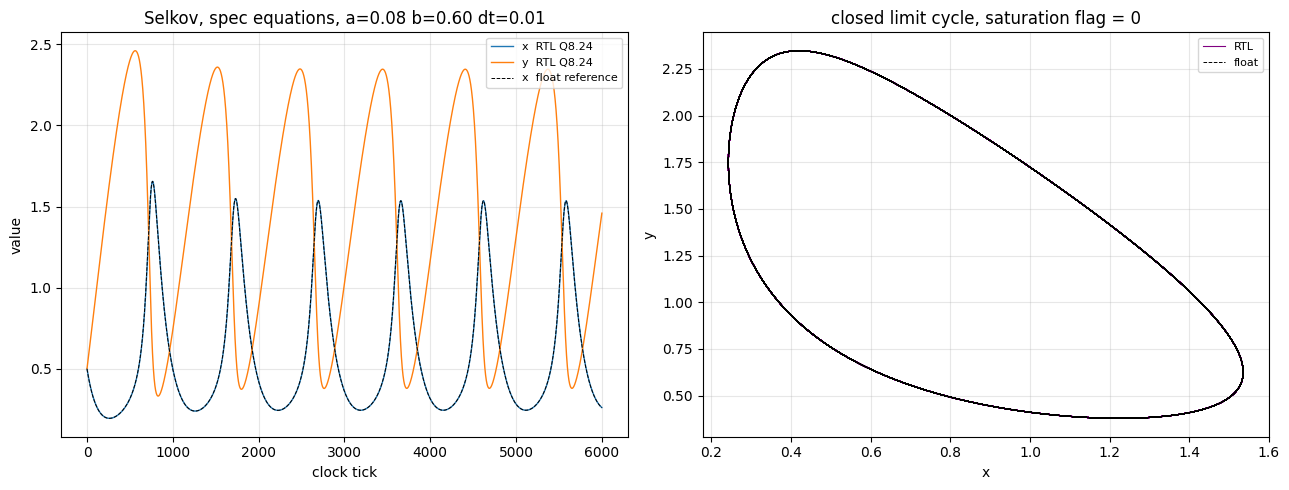

In [ ]:
fig,(A,B)=plt.subplots(1,2,figsize=(13,5))
A.plot(d.tick[:6000], x[:6000], lw=1, label='x  RTL Q8.24')
A.plot(d.tick[:6000], y[:6000], lw=1, label='y  RTL Q8.24')
A.plot(d.tick[:6000], rx[:6000], 'k--', lw=.7, label='x  float reference')
A.set_xlabel('clock tick'); A.set_ylabel('value'); A.grid(alpha=.3); A.legend(fontsize=8)
A.set_title('Selkov, spec equations, a=0.08 b=0.60 dt=0.01')
B.plot(x[20000:], y[20000:], lw=.8, color='purple', label='RTL')
B.plot(rx[20000:], ry[20000:], 'k--', lw=.7, label='float')
B.set_xlabel('x'); B.set_ylabel('y'); B.grid(alpha=.3); B.legend(fontsize=8)
B.set_title(f'closed limit cycle, saturation flag = {int(d.sat.max())}')
plt.tight_layout(); plt.savefig("selkov_limit_cycle.png", dpi=160); plt.show()

## 5. What this run establishes

| claim | status |
|---|---|
| RTL implements the stated equations | **verified** — max deviation from float integration of the same ODEs |
| no arithmetic overflow occurred | **verified** — sticky saturation flag read 0 |
| the orbit is a closed limit cycle | **verified** — returns to itself each period, no accumulating drift |
| fast Goldilocks reduction is correct | **verified** — bit-identical to `%` on 20,006 vectors incl. edge cases |
| fast reduction is cheaper than a divider | **measured** — gate-count ratio above |
| this generates ZK proofs | **NO** — no constraint system, no commitment, no verifier |
| this runs on an FPGA | **NOT TESTED** — needs Vivado and a board; Yosys gives area only |
| this self-improves | **NO** — a, b, dt are inputs; nothing writes to them |

### Honest next steps

1. **Throughput benchmark.** Time N Selkov steps in numpy/C, compare against one-state-per-clock
   at a plausible Fmax. That is a real speedup number with a real baseline.
2. **Vivado synthesis** on a part you can actually target, for Fmax and DSP utilisation.
3. **If ZK is the goal**, the accelerator literature targets MSM and NTT, not witness generation.
   A Goldilocks multiplier is a building block for NTT — that is the honest path from here.
